# Model Comparison: Development of RL Strategies Across Training

Fits models separately for each training stage (4.6, 4.7, 4.8) and plots how
RL strategies develop across training.

**Workflow:**
- Each (model, stage) pair is fitted independently.
- Results are cached as CSVs; set `FORCE_REFIT = True` to redo.
- After all results are collected, developmental comparison plots are produced.

In [1]:
# ============================================================
# CONFIGURATION
# ============================================================

MODELS_TO_COMPARE = [
    "mf_p", "mf_pmulti",
    "mb_p", "mb_pmulti",
    "hyb_p", "hyb_pmulti",
    "ls_asym", "ls_asym_p", "ls_asym_pmulti",
    "rac_p",
]

# Stages to fit and compare (order = developmental order)
# None → stage 4.8 (data/raw/WT1)
# '4.7' / '4.6' → training data (data/raw/WT1_Training), filtered by training_stage
STAGES = ["4.6", "4.7", None]   # None = stage 4.8

FORCE_REFIT = False  # set True to ignore cached CSVs and refit everything

In [2]:
import sys, os
import subprocess
# Resolve organized/ from the notebook file location
_nb_dir = os.path.abspath(os.getcwd())
# Walk up until we find a directory containing config.py
_d = _nb_dir
for _ in range(5):
    if os.path.isfile(os.path.join(_d, "config.py")):
        break
    _d = os.path.dirname(_d)
sys.path.insert(0, os.path.join(_d, "src"))
sys.path.insert(0, _d)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import pystan
import nest_asyncio
nest_asyncio.apply()

import data_import as di
from models import get_model
from fitting import RL_data_arrange, LOO
from config import SUBJECTS, cv_result_csv, raw_subject_dir

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
})

def stage_label(stage):
    """Convert stage value to display/filename string."""
    return stage if stage is not None else "4.8"

STAGE_LABELS = [stage_label(s) for s in STAGES]
print(f"Stages: {STAGE_LABELS}")
print(f"Models: {MODELS_TO_COMPARE}")
print(f"Subjects: {SUBJECTS}")

Stages: ['4.6', '4.7', '4.8']
Models: ['mf_p', 'mf_pmulti', 'mb_p', 'mb_pmulti', 'hyb_p', 'hyb_pmulti', 'ls_asym', 'ls_asym_p', 'ls_asym_pmulti', 'rac_p']
Subjects: ['WT1', 'WT2', 'WT3', 'WT4', 'WT5', 'WT6']


In [3]:
# ── Load session data for each stage separately ────────────────────────────
def load_sessions(subject, training_stage):
    """Load sessions for one subject for a single training stage."""
    if training_stage in ("4.6", "4.7"):
        exp = di.Experiment(raw_subject_dir(subject, training=True))
        exp.save()
        return [s for s in exp.get_sessions(subject_IDs="all")
                if s.training_stage == training_stage]
    else:
        # None → stage 4.8 only
        exp = di.Experiment(raw_subject_dir(subject, training=False))
        exp.save()
        return exp.get_sessions(subject_IDs="all")


# mice_data_by_stage[lbl][subject] = (S, T, T_max, c, ss, tt, r, PR, PL)
mice_data_by_stage = {}

for stage, lbl in zip(STAGES, STAGE_LABELS):
    print(f"\n=== Stage {lbl} ===")
    mice_data_by_stage[lbl] = {}
    for subject in SUBJECTS:
        sessions = load_sessions(subject, stage)
        if not sessions:
            print(f"  {subject}: no sessions found")
            continue
        S, T, c, ss, tt, r, PR, PL = RL_data_arrange(sessions)
        mice_data_by_stage[lbl][subject] = (S, T, max(T), c, ss, tt, r, PR, PL)
        print(f"  {subject}: {S} sessions")


=== Stage 4.6 ===
Saved sessions loaded from: sessions.pkl
  WT1: 5 sessions
Saved sessions loaded from: sessions.pkl
  WT2: 11 sessions
Saved sessions loaded from: sessions.pkl
  WT3: 11 sessions
Saved sessions loaded from: sessions.pkl
  WT4: 6 sessions
Saved sessions loaded from: sessions.pkl
  WT5: 9 sessions
Saved sessions loaded from: sessions.pkl
  WT6: 2 sessions

=== Stage 4.7 ===
Saved sessions loaded from: sessions.pkl
  WT1: 10 sessions
Saved sessions loaded from: sessions.pkl
  WT2: 2 sessions
Saved sessions loaded from: sessions.pkl
  WT3: 3 sessions
Saved sessions loaded from: sessions.pkl
  WT4: 8 sessions
Saved sessions loaded from: sessions.pkl
  WT5: 5 sessions
Saved sessions loaded from: sessions.pkl
  WT6: 7 sessions

=== Stage 4.8 ===
Saved sessions loaded from: sessions.pkl
  WT1: 11 sessions
Saved sessions loaded from: sessions.pkl
  WT2: 17 sessions
Saved sessions loaded from: sessions.pkl
  WT3: 14 sessions
Saved sessions loaded from: sessions.pkl
  WT4: 15 s

In [4]:
# ── Fit or load each (model, stage) pair ──────────────────────────────────
# all_dfs[(model_name, stage_lbl)] = DataFrame
all_dfs = {}

for model_name in MODELS_TO_COMPARE:
    model = None  # compile Stan lazily, only if needed
    sm = None

    for lbl in STAGE_LABELS:
        csv_path = cv_result_csv(model_name, lbl)

        if not FORCE_REFIT and os.path.exists(csv_path):
            print(f'[{model_name} | {lbl}] Loading from {csv_path}')
            all_dfs[(model_name, lbl)] = pd.read_csv(csv_path)
            continue

        # Compile Stan once per model (shared across stages)
        if sm is None:
            print(f'\n[{model_name}] Compiling Stan model...')
            model = get_model(model_name)
            sm = pystan.StanModel(model_code=model.stan_code)
        if model is None:
            model = get_model(model_name)

        mice_data = mice_data_by_stage.get(lbl, {})
        if not mice_data:
            print(f'[{model_name} | {lbl}] No data — skipping')
            continue

        print(f'\n[{model_name} | {lbl}] Fitting...')
        rows = []
        for subject, data in mice_data.items():
            S, T, T_max, c, ss, tt, r, PR, PL = data
            print(f'  {subject} (S={S})')
            nl, param = LOO(model, sm, S, T, T_max, c, ss, tt, r, PL, PR)
            row = {'Subject': subject, 'Cross validation': np.exp(np.mean(nl))}
            for p in model.param_names:
                if p in param:
                    row[p] = param[p]
            rows.append(row)

        df = pd.DataFrame(rows)
        df.to_csv(csv_path, index=False)
        print(f'  Saved → {csv_path}')
        all_dfs[(model_name, lbl)] = df

print('\nDone. Keys:', list(all_dfs.keys()))

[mf_p | 4.6] Loading from /gpfs/radev/project/kuan/my483/RL_twostep/twostep-model-comparison/results/CV/CV_mf_p_4.6.csv
[mf_p | 4.7] Loading from /gpfs/radev/project/kuan/my483/RL_twostep/twostep-model-comparison/results/CV/CV_mf_p_4.7.csv
[mf_p | 4.8] Loading from /gpfs/radev/project/kuan/my483/RL_twostep/twostep-model-comparison/results/CV/CV_mf_p_4.8.csv
[mf_pmulti | 4.6] Loading from /gpfs/radev/project/kuan/my483/RL_twostep/twostep-model-comparison/results/CV/CV_mf_pmulti_4.6.csv
[mf_pmulti | 4.7] Loading from /gpfs/radev/project/kuan/my483/RL_twostep/twostep-model-comparison/results/CV/CV_mf_pmulti_4.7.csv
[mf_pmulti | 4.8] Loading from /gpfs/radev/project/kuan/my483/RL_twostep/twostep-model-comparison/results/CV/CV_mf_pmulti_4.8.csv
[mb_p | 4.6] Loading from /gpfs/radev/project/kuan/my483/RL_twostep/twostep-model-comparison/results/CV/CV_mb_p_4.6.csv
[mb_p | 4.7] Loading from /gpfs/radev/project/kuan/my483/RL_twostep/twostep-model-comparison/results/CV/CV_mb_p_4.7.csv
[mb_p | 4.

In [5]:
# ── Build combined long-format DataFrame ──────────────────────────────────
combined_rows = []
for (model_name, lbl), df in all_dfs.items():
    tmp = df.copy()
    tmp['Model'] = model_name
    tmp['Stage'] = lbl
    combined_rows.append(tmp)
combined = pd.concat(combined_rows, ignore_index=True)

# Ordered stage categorical so plots sort correctly
combined['Stage'] = pd.Categorical(combined['Stage'],
                                   categories=STAGE_LABELS, ordered=True)

combined['Family'] = combined['Model'].map({
    'mf_p': 'MF',               'mf_pmulti': 'MF',
    'mb_p': 'MB',               'mb_pmulti': 'MB',
    'hyb_p': 'Hybrid',          'hyb_pmulti': 'Hybrid',
    'ls_asym': 'Latent State',  'ls_asym_p': 'Latent State',  'ls_asym_pmulti': 'Latent State',
    'rac_p': 'Reward as Cue',
})
combined['Perseveration'] = combined['Model'].map({
    'mf_p': 'Single',       'mf_pmulti': 'Multi',
    'mb_p': 'Single',       'mb_pmulti': 'Multi',
    'hyb_p': 'Single',      'hyb_pmulti': 'Multi',
    'ls_asym': 'None',      'ls_asym_p': 'Single',  'ls_asym_pmulti': 'Multi',
    'rac_p': 'Single',
})

print(combined[['Subject', 'Stage', 'Model', 'Cross validation']].head(12))

   Subject Stage Model  Cross validation
0      WT1   4.6  mf_p          0.498335
1      WT2   4.6  mf_p          0.505400
2      WT3   4.6  mf_p          0.515158
3      WT4   4.6  mf_p          0.523168
4      WT5   4.6  mf_p          0.526860
5      WT6   4.6  mf_p          0.534113
6      WT1   4.7  mf_p          0.546282
7      WT2   4.7  mf_p          0.519343
8      WT3   4.7  mf_p          0.526901
9      WT4   4.7  mf_p          0.524695
10     WT5   4.7  mf_p          0.546959
11     WT6   4.7  mf_p          0.566656


In [6]:
# ── Plotting helper: line plot across stages ───────────────────────────────
def plot_across_stages(ax, data, col, hue, hue_order, stage_order,
                       subject_col='Subject', ylabel=None, ylim=None,
                       palette=None, chance=None):
    """
    Line plot with stage on x-axis. One line per hue value (model/family/etc).
    Shows mean ± SEM band and individual subject traces.
    """
    if palette is None:
        palette = dict(zip(hue_order, plt.cm.tab10.colors))

    x_pos = {lbl: i for i, lbl in enumerate(stage_order)}
    subjects = data[subject_col].unique()

    for hval in hue_order:
        color = palette.get(hval, 'gray')
        sub = data[data[hue] == hval]

        # --- individual subject traces (thin, alpha) ---
        for subj in subjects:
            xs, ys = [], []
            for lbl in stage_order:
                row = sub[(sub[subject_col] == subj) & (sub['Stage'] == lbl)]
                if not row.empty and col in row.columns and pd.notna(row[col].values[0]):
                    xs.append(x_pos[lbl])
                    ys.append(row[col].values[0])
            if len(xs) > 1:
                ax.plot(xs, ys, color=color, lw=0.8, alpha=0.25, zorder=1)

        # --- mean ± SEM ---
        means, sems, xs_mean = [], [], []
        for lbl in stage_order:
            vals = sub[sub['Stage'] == lbl][col].dropna().values
            if len(vals) == 0:
                continue
            means.append(vals.mean())
            sems.append(vals.std() / np.sqrt(len(vals)))
            xs_mean.append(x_pos[lbl])

        means = np.array(means)
        sems  = np.array(sems)
        ax.fill_between(xs_mean, means - sems, means + sems,
                        color=color, alpha=0.18, zorder=2)
        ax.plot(xs_mean, means, color=color, lw=2.2,
                marker='o', ms=5, zorder=3, label=hval)

    if chance is not None:
        ax.axhline(chance, color='black', lw=1, ls='--', alpha=0.45, label='chance')

    ax.set_xticks(list(x_pos.values()))
    ax.set_xticklabels([f'Stage {l}' for l in stage_order], fontsize=9)
    ax.set_xlabel('Training stage')
    if ylabel:
        ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(ylim)

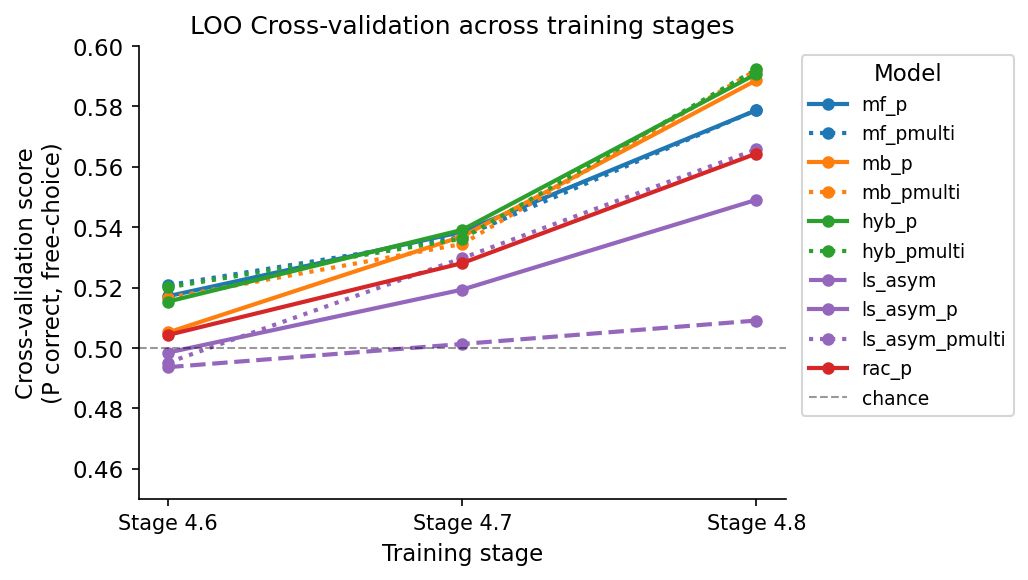

In [7]:
# ── Plot 1: CV across stages, mean only ───────────────────────────────────
# Same color per family; solid = single-P, dotted = multi-P, dashed = no-P
FAMILY_COLORS = {
    'MF':             '#1f77b4',
    'MB':             '#ff7f0e',
    'Hybrid':         '#2ca02c',
    'Latent State':   '#9467bd',
    'Reward as Cue':  '#d62728',
}
MODEL_FAMILY = {
    'mf_p': 'MF',             'mf_pmulti': 'MF',
    'mb_p': 'MB',             'mb_pmulti': 'MB',
    'hyb_p': 'Hybrid',        'hyb_pmulti': 'Hybrid',
    'ls_asym': 'Latent State','ls_asym_p': 'Latent State', 'ls_asym_pmulti': 'Latent State',
    'rac_p': 'Reward as Cue',
}
MODEL_LS = {m: (':' if 'pmulti' in m else ('--' if m == 'ls_asym' else '-'))
            for m in MODELS_TO_COMPARE}

x_pos = {lbl: i for i, lbl in enumerate(STAGE_LABELS)}

fig, ax = plt.subplots(figsize=(7, 4))

for model_name in MODELS_TO_COMPARE:
    color = FAMILY_COLORS[MODEL_FAMILY[model_name]]
    ls    = MODEL_LS[model_name]
    sub   = combined[combined['Model'] == model_name]

    xs, ys = [], []
    for lbl in STAGE_LABELS:
        vals = sub[sub['Stage'] == lbl]['Cross validation'].dropna().values
        if len(vals):
            xs.append(x_pos[lbl])
            ys.append(vals.mean())

    ax.plot(xs, ys, color=color, ls=ls, lw=2, marker='o', ms=5, label=model_name)

ax.axhline(0.5, color='black', lw=1, ls='--', alpha=0.4, label='chance')
ax.set_xticks(list(x_pos.values()))
ax.set_xticklabels([f'Stage {l}' for l in STAGE_LABELS], fontsize=10)
ax.set_xlabel('Training stage')
ax.set_ylabel('Cross-validation score\n(P correct, free-choice)')
ax.set_ylim(0.45, 0.6)
ax.set_title('LOO Cross-validation across training stages')
ax.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join('..', 'figures', 'cv_across_stages.pdf'), bbox_inches='tight')
plt.show()

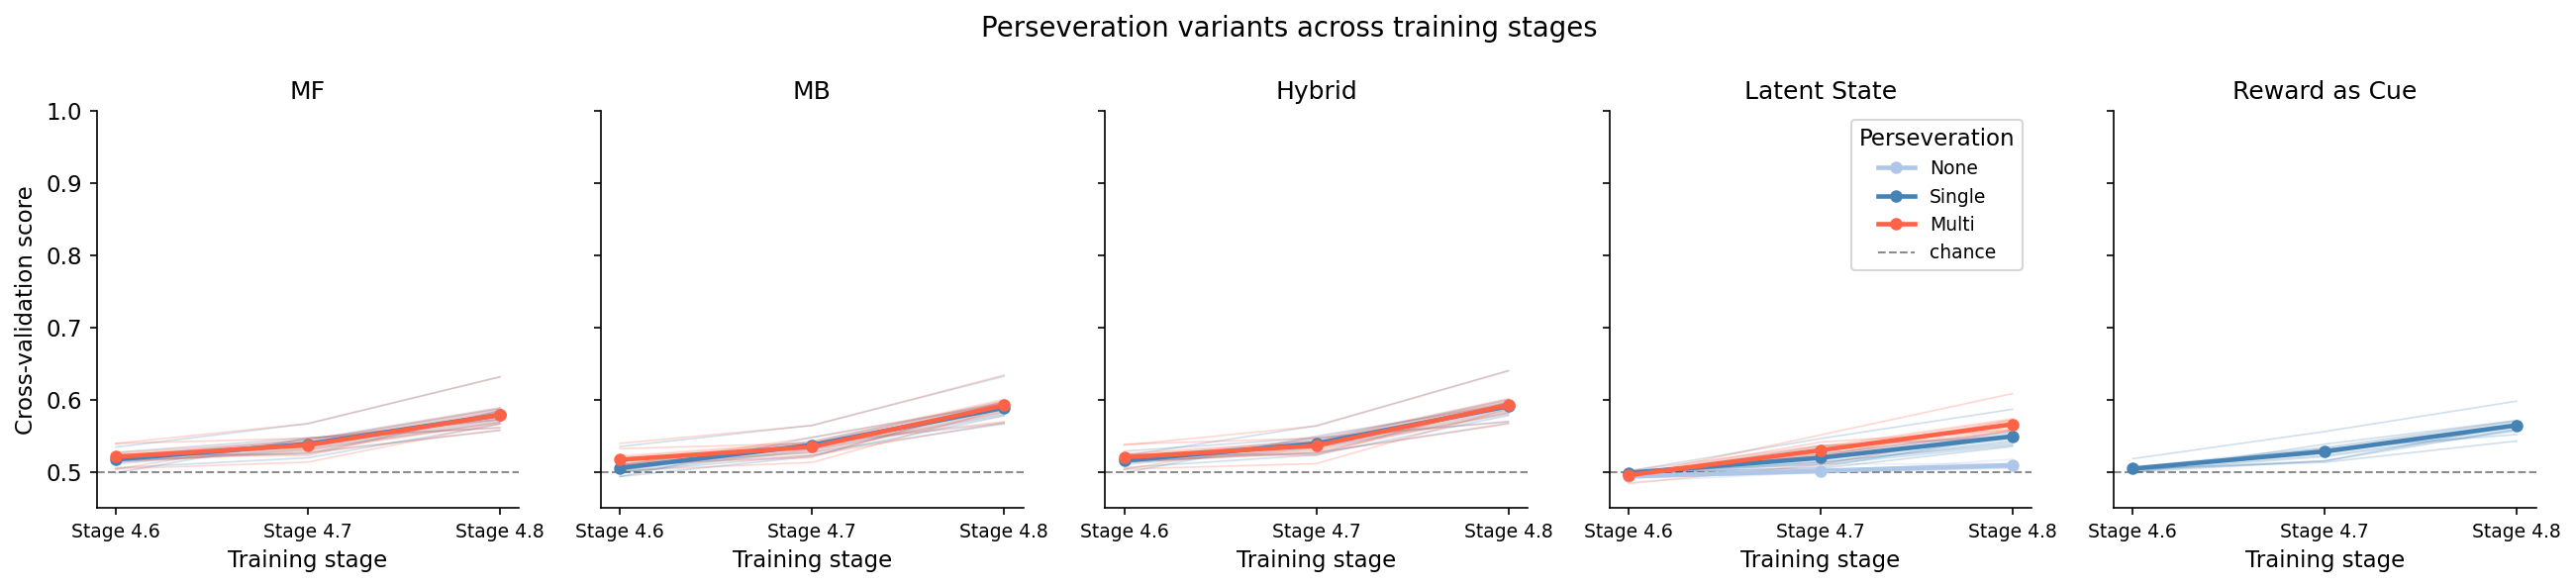

In [8]:
# ── Plot 2: CV by family — perseveration variants across stages ────────────
families = ['MF', 'MB', 'Hybrid', 'Latent State', 'Reward as Cue']
PERSEV_COLORS = {'None': '#aec7e8', 'Single': 'steelblue', 'Multi': 'tomato'}

n_fam = len(families)
fig, axes = plt.subplots(1, n_fam, figsize=(3.5 * n_fam, 4), sharey=True)

for ax, family in zip(axes, families):
    sub = combined[combined['Family'] == family]
    persev_present = [p for p in ['None', 'Single', 'Multi']
                      if p in sub['Perseveration'].dropna().unique()]

    plot_across_stages(
        ax, sub,
        col='Cross validation',
        hue='Perseveration', hue_order=persev_present,
        stage_order=STAGE_LABELS,
        ylabel='Cross-validation score' if family == 'MF' else None,
        ylim=(0.45, 1.0),
        palette=PERSEV_COLORS,
        chance=0.5,
    )
    ax.set_title(family)
    if family == 'Latent State':
        ax.legend(title='Perseveration', fontsize=9)

fig.suptitle('Perseveration variants across training stages')
plt.tight_layout()
plt.savefig(os.path.join('..', 'figures', 'single_vs_multi_across_stages.pdf'), bbox_inches='tight')
plt.show()

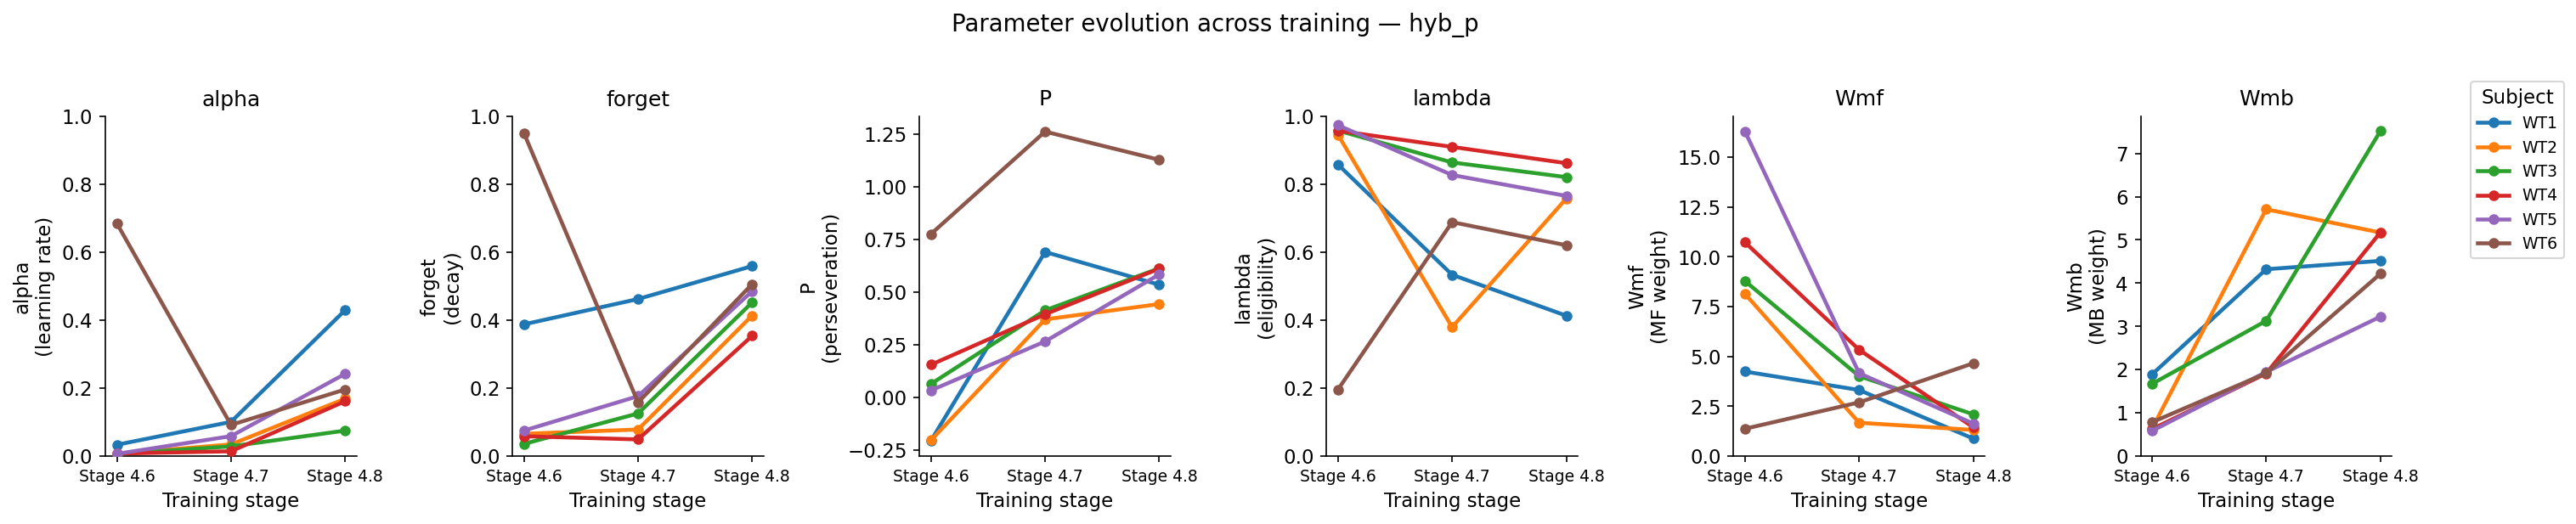

In [9]:
# ── Plot 3: Parameter evolution across stages ──────────────────────────────
# Choose model to inspect (must be in MODELS_TO_COMPARE)
PARAM_MODEL = 'hyb_p'

PARAM_GROUPS = [
    # (param_col, display_label, ylim)
    ('alpha',   'alpha\n(learning rate)',  (0, 1)),
    ('forget',  'forget\n(decay)',         (0, 1)),
    ('P',       'P\n(perseveration)',      None),
    ('lambda',  'lambda\n(eligibility)',   (0, 1)),
    ('Wmf',     'Wmf\n(MF weight)',        (0, None)),
    ('Wmb',     'Wmb\n(MB weight)',        (0, None)),
    ('alpha_c', 'alpha_c\n(EMA persev.)',  (0, 1)),
]

sub = combined[combined['Model'] == PARAM_MODEL]
# Only show params that exist for this model
valid_params = [(p, lbl, ylim) for p, lbl, ylim in PARAM_GROUPS
                if p in sub.columns and sub[p].notna().any()]

fig, axes = plt.subplots(1, len(valid_params), figsize=(3.2 * len(valid_params), 4))
if len(valid_params) == 1:
    axes = [axes]

for ax, (param, lbl, ylim) in zip(axes, valid_params):
    plot_across_stages(
        ax, sub,
        col=param,
        hue='Subject', hue_order=list(sub['Subject'].unique()),
        stage_order=STAGE_LABELS,
        ylabel=lbl,
        ylim=ylim,
    )
    ax.set_title(param)
    ax.get_legend_handles_labels()  # suppress per-axis legend

# Single legend for subjects
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title='Subject',
           bbox_to_anchor=(1.01, 0.9), loc='upper left', fontsize=9)

fig.suptitle(f'Parameter evolution across training — {PARAM_MODEL}', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join('..', 'figures', f'params_across_stages_{PARAM_MODEL}.pdf'),
            bbox_inches='tight')
plt.show()

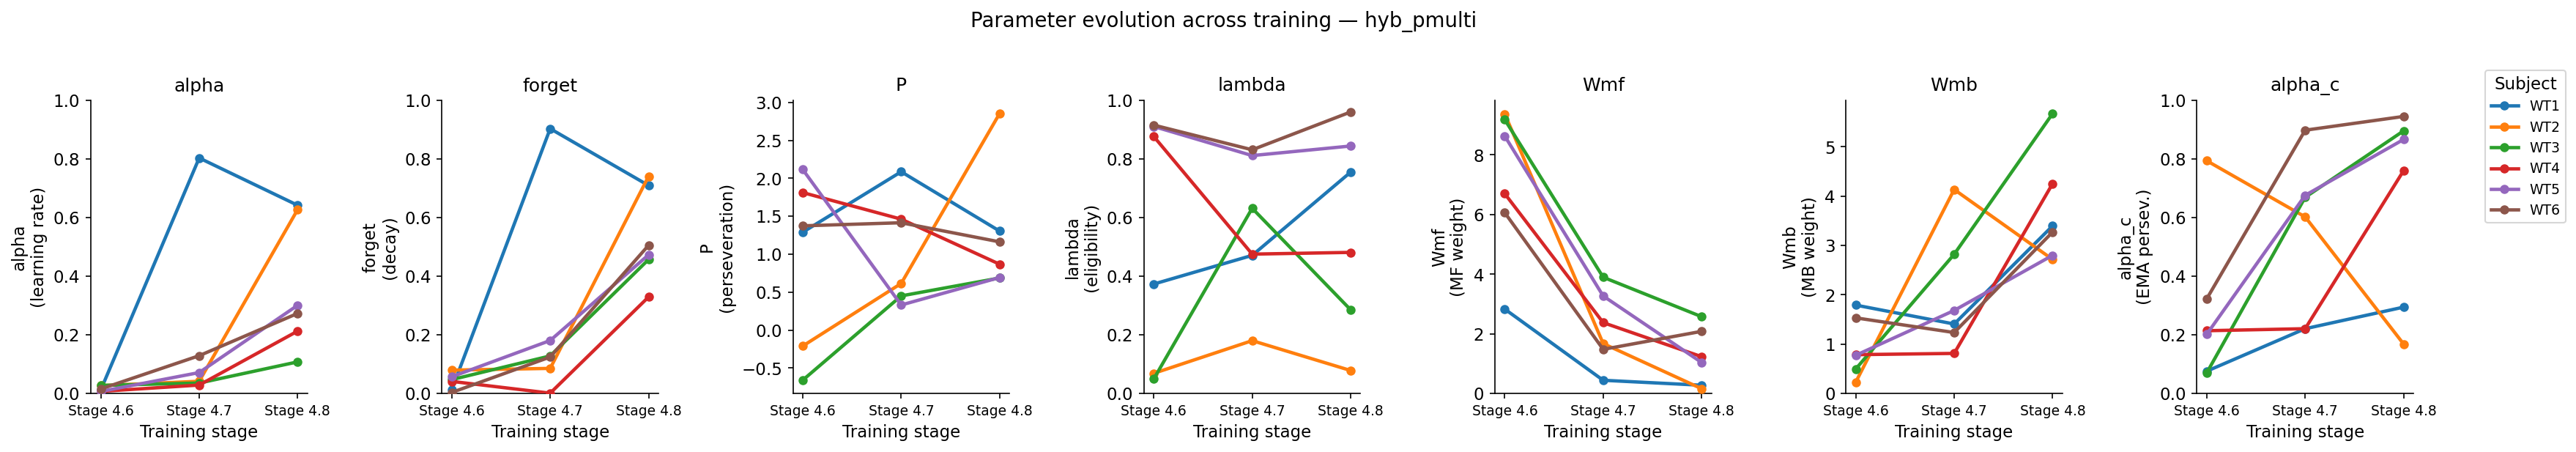

In [10]:
# ── Plot 3: Parameter evolution across stages ──────────────────────────────
# Choose model to inspect (must be in MODELS_TO_COMPARE)
PARAM_MODEL = 'hyb_pmulti'

PARAM_GROUPS = [
    # (param_col, display_label, ylim)
    ('alpha',   'alpha\n(learning rate)',  (0, 1)),
    ('forget',  'forget\n(decay)',         (0, 1)),
    ('P',       'P\n(perseveration)',      None),
    ('lambda',  'lambda\n(eligibility)',   (0, 1)),
    ('Wmf',     'Wmf\n(MF weight)',        (0, None)),
    ('Wmb',     'Wmb\n(MB weight)',        (0, None)),
    ('alpha_c', 'alpha_c\n(EMA persev.)',  (0, 1)),
]

sub = combined[combined['Model'] == PARAM_MODEL]
# Only show params that exist for this model
valid_params = [(p, lbl, ylim) for p, lbl, ylim in PARAM_GROUPS
                if p in sub.columns and sub[p].notna().any()]

fig, axes = plt.subplots(1, len(valid_params), figsize=(3.2 * len(valid_params), 4))
if len(valid_params) == 1:
    axes = [axes]

for ax, (param, lbl, ylim) in zip(axes, valid_params):
    plot_across_stages(
        ax, sub,
        col=param,
        hue='Subject', hue_order=list(sub['Subject'].unique()),
        stage_order=STAGE_LABELS,
        ylabel=lbl,
        ylim=ylim,
    )
    ax.set_title(param)
    ax.get_legend_handles_labels()  # suppress per-axis legend

# Single legend for subjects
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title='Subject',
           bbox_to_anchor=(1.01, 0.9), loc='upper left', fontsize=9)

fig.suptitle(f'Parameter evolution across training — {PARAM_MODEL}', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join('..', 'figures', f'params_across_stages_{PARAM_MODEL}.pdf'),
            bbox_inches='tight')
plt.show()

In [11]:
# ── Summary pivot table: Model × Stage ────────────────────────────────────
pivot = (combined
         .groupby(['Model', 'Stage'])['Cross validation']
         .agg(['mean', 'sem'])
         .round(4)
         .unstack('Stage'))

# Reorder rows to match MODELS_TO_COMPARE
pivot = pivot.loc[[m for m in MODELS_TO_COMPARE if m in pivot.index]]
pivot

mean                     sem                
Stage              4.6     4.7     4.8     4.6     4.7     4.8
Model                                                         
mf_p            0.5172  0.5385  0.5788  0.0055  0.0073  0.0112
mf_pmulti       0.5208  0.5368  0.5788  0.0066  0.0081  0.0112
mb_p            0.5052  0.5370  0.5887  0.0064  0.0068  0.0101
mb_pmulti       0.5166  0.5345  0.5921  0.0062  0.0079  0.0098
hyb_p           0.5154  0.5391  0.5908  0.0047  0.0068  0.0110
hyb_pmulti      0.5201  0.5362  0.5923  0.0063  0.0079  0.0108
ls_asym         0.4937  0.5014  0.5091  0.0020  0.0019  0.0019
ls_asym_p       0.4985  0.5194  0.5491  0.0009  0.0070  0.0079
ls_asym_pmulti  0.4952  0.5298  0.5658  0.0026  0.0063  0.0091
rac_p           0.5043  0.5281  0.5644  0.0029  0.0069  0.0078